In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.59G/1.59G [00:14<00:00, 119MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1):
['dataset']


In [ ]:
import os

# Explore the structure inside the drone-vs-bird dataset
# The previous cell showed the contents of 'path' is ['dataset']
drone_dataset_path = os.path.join(path, 'dataset')

if os.path.exists(drone_dataset_path):
    print(f"Subdirectories in drone dataset: {os.listdir(drone_dataset_path)}")
else:
    print(f"Directory {drone_dataset_path} does not exist. Please check the file structure.")

Subdirectories in drone dataset: ['bird', 'drone']


Found 4104 images. Displaying 6 sample images:


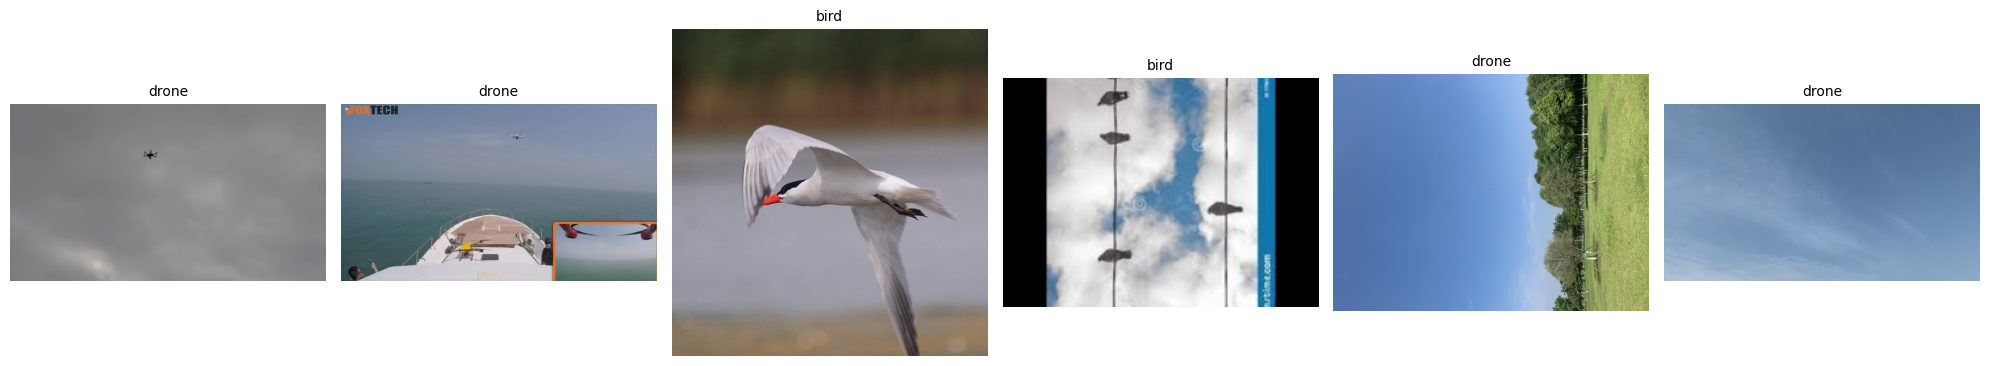

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the path defined in cell 2 for the drone dataset
drone_dataset_path = os.path.join(path, 'dataset')
display_sample_images(drone_dataset_path)

In [ ]:
!pip install split-folders

In [ ]:
import os
# Ensure the library is available in the current environment
!pip install split-folders

import splitfolders

# Input folder from the drone-vs-bird dataset
input_folder = os.path.join(path, 'dataset')
output_folder = '/content/drone_bird_split'

# Create output directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Split data: train=0.8, val=0.2
if os.path.exists(input_folder):
    print(f"Splitting files from {input_folder} to {output_folder}...")
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Data successfully split into: {output_folder}")
    print(f"Subdirectories created: {os.listdir(output_folder)}")
else:
    print(f"Error: Input directory {input_folder} not found.")

Splitting files from /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1/dataset to /content/drone_bird_split...


Copying files: 4106 files [00:09, 432.67 files/s]

Data successfully split into: /content/drone_bird_split
Subdirectories created: ['val', 'train']


In [ ]:
def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')

train_count = count_files(train_dir)
val_count = count_files(val_dir)
total = train_count + val_count

print(f"Dataset Split Statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Val (Test) Set: {val_count} images ({val_count/total*100:.1f}%)")
print(f"- Total: {total} images")

Dataset Split Statistics:
- Train Set: 3284 images (80.0%)
- Val (Test) Set: 822 images (20.0%)
- Total: 4106 images


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# Basic configuration
BATCH_SIZE = 32
IMG_HEIGHT = 227
IMG_WIDTH = 227
EPOCHS = 10

Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Data preparation
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# AlexNet Architecture
model = Sequential([
    Conv2D(96, kernel_size=(11, 11), strides=(4, 4), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    Conv2D(256, kernel_size=(5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
    Conv2D(384, kernel_size=(3, 3), padding='same', activation='relu'),
    Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 3282 images belonging to 2 classes.
Found 822 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,286,849 (222.35 MB)

 Trainable params: 58,286,145 (222.34 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 86s 719ms/step - accuracy: 0.7367 - loss: 1.6274 - val_accuracy: 0.5401 - val_loss: 0.6468
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 57s 559ms/step - accuracy: 0.8199 - loss: 0.4146 - val_accuracy: 0.8273 - val_loss: 0.4683
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 570ms/step - accuracy: 0.8413 - loss: 0.3688 - val_accuracy: 0.8577 - val_loss: 0.3319
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 560ms/step - accuracy: 0.8601 - loss: 0.3363 - val_accuracy: 0.8820 - val_loss: 0.2893
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 59s 569ms/step - accuracy: 0.8534 - loss: 0.3368 - val_accuracy: 0.8869 - val_loss: 0.3013
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 562ms/step - accuracy: 0.8699 - loss: 0.3074 - val_accuracy: 0.8796 - val_loss: 0.3258
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 562ms/step - accuracy: 0.8729 - loss: 0.2933 - val_accuracy: 0.8321 - val_loss: 0.3899
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 563ms/step - accuracy: 0.8857 - loss: 0

In [ ]:
# Evaluate and summarize results
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 454ms/step - accuracy: 0.9075 - loss: 0.2582
Validation Loss: 0.2582
Validation Accuracy: 0.9075


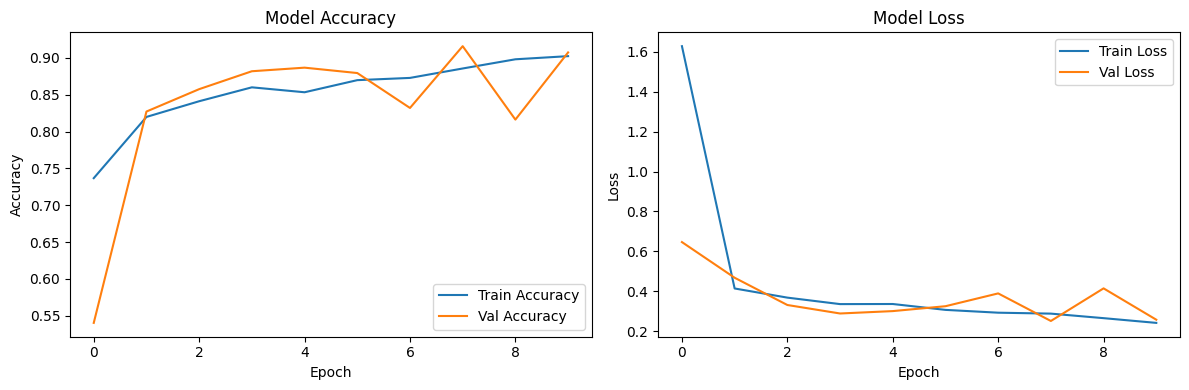

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()